In [14]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os

# تحقق إن الملف موجود
path = '/content/drive/MyDrive/Bank-Churn-Project/data/row/Churn_Modelling.csv'

if os.path.exists(path):
    print('الملف موجود!')
else:
    print('الملف مش موجود — تأكد من المسار')

الملف موجود!


In [16]:
import pandas as pd

path = '/content/drive/MyDrive/Bank-Churn-Project/data/row/Churn_Modelling.csv'

df = pd.read_csv(path)
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [18]:
print(df['Exited'].value_counts())
print('---')
print(df['Exited'].value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64
---
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [19]:
print(df['Exited'].value_counts())
print('---')
print(df['Exited'].value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64
---
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


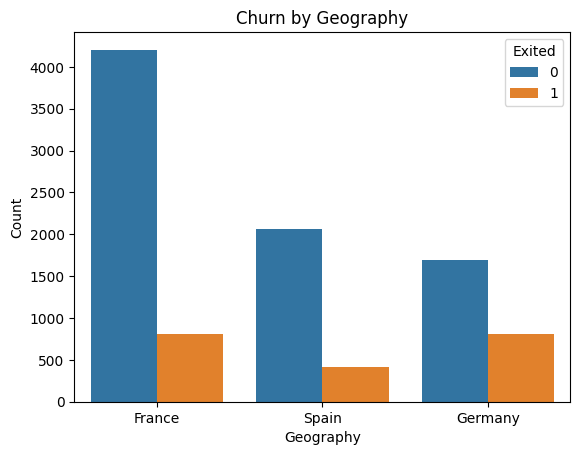

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()

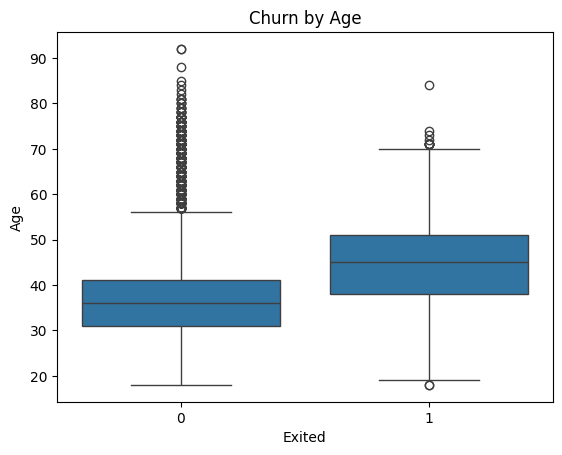

In [21]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Churn by Age')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.show()

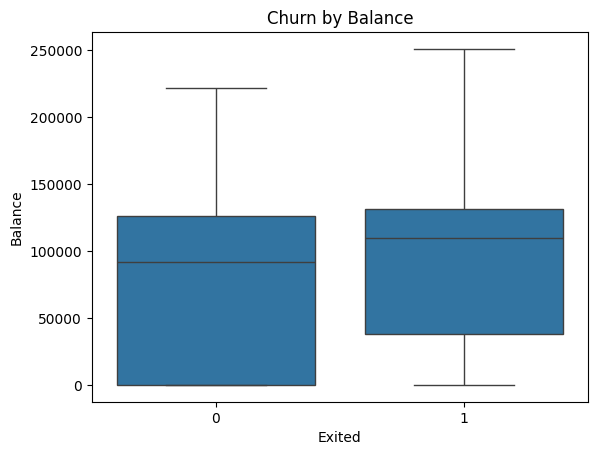

In [22]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Churn by Balance')
plt.xlabel('Exited')
plt.ylabel('Balance')
plt.show()

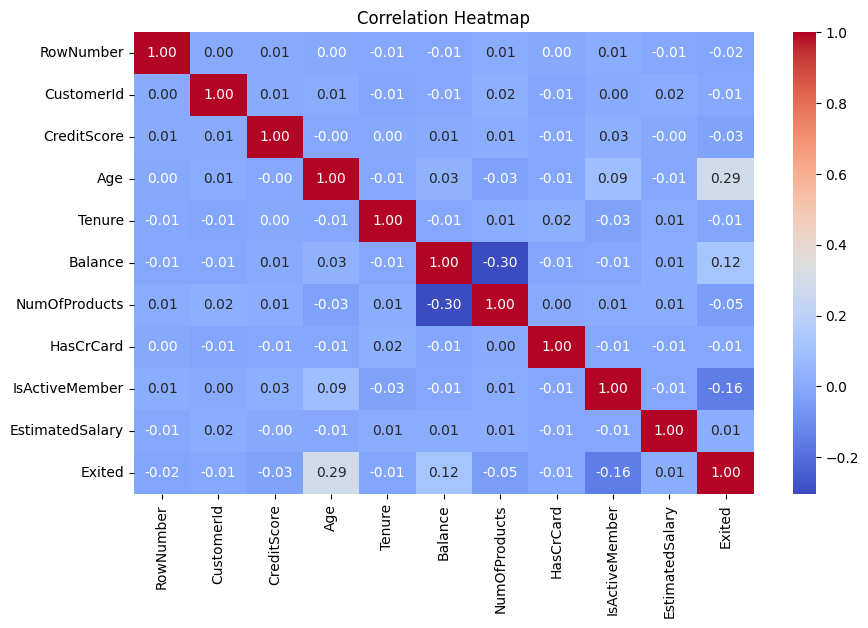

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [24]:

df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)


df = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True)

print(df.shape)
df.head()


(10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [ ]:
# ── Save cleaned data ────────────────────────────────────
import os

processed_dir = '/content/drive/MyDrive/Bank-Churn-Project/data/processed'
os.makedirs(processed_dir, exist_ok=True)

df.to_csv(f'{processed_dir}/cleaned_data.csv', index=False)

print(f'✅ cleaned_data.csv saved — Shape: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')


In [25]:
print(df.columns.tolist())

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Gender_Male', 'Geography_Germany', 'Geography_Spain']


In [26]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (10000, 11)
y shape: (10000,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('قبل SMOTE:', y_train.value_counts().to_dict())
print('بعد SMOTE:', y_train_sm.value_counts().to_dict())

قبل SMOTE: {0: 6356, 1: 1644}
بعد SMOTE: {0: 6356, 1: 6356}


In [31]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_sm, y_train_sm)

y_pred_rf = model_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.59      0.60      0.60       393

    accuracy                           0.84      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000



In [32]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
model_xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1607
           1       0.65      0.57      0.61       393

    accuracy                           0.85      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.85      0.85      0.85      2000



In [ ]:
import joblib
import os

# ── Create models directory ───────────────────────────────
save_dir = '/content/drive/MyDrive/Bank-Churn-Project/models'
os.makedirs(save_dir, exist_ok=True)

# ── Save Scaler ───────────────────────────────────────────
joblib.dump(scaler, f'{save_dir}/scaler.pkl')
print('✅ scaler.pkl saved')

# ── Save Logistic Regression ──────────────────────────────
joblib.dump(model_lr, f'{save_dir}/logistic_regression.pkl')
print('✅ logistic_regression.pkl saved')

# ── Save Random Forest ────────────────────────────────────
joblib.dump(model_rf, f'{save_dir}/random_forest.pkl')
print('✅ random_forest.pkl saved')

# ── Save XGBoost (default) ────────────────────────────────
joblib.dump(model_xgb, f'{save_dir}/xgboost_model.pkl')
print('✅ xgboost_model.pkl saved')

# ── Save XGBoost (tuned) — Best Model ─────────────────────
joblib.dump(model_xgb_tuned, f'{save_dir}/xgboost_tuned.pkl')
print('✅ xgboost_tuned.pkl saved')

# ── Save feature names ────────────────────────────────────
joblib.dump(X.columns.tolist(), f'{save_dir}/feature_names.pkl')
print('✅ feature_names.pkl saved')

print(f'
🎉 All models saved to: {save_dir}')
print(f'   Files: {os.listdir(save_dir)}')


In [34]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_sm, y_train_sm)

print('Best params:', grid.best_params_)

Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


In [35]:
model_xgb_tuned = XGBClassifier(
    learning_rate=0.2,
    max_depth=7,
    n_estimators=300,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

model_xgb_tuned.fit(X_train_sm, y_train_sm)

y_pred_tuned = model_xgb_tuned.predict(X_test)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1607
           1       0.65      0.55      0.60       393

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.85      0.85      0.85      2000



In [36]:
y_pred_proba = model_xgb_tuned.predict_proba(X_test)[:, 1]
y_pred_threshold = (y_pred_proba >= 0.4).astype(int)

print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.60      0.60      0.60       393

    accuracy                           0.84      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000



In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model_xgb_tuned,
    X_train_sm,
    y_train_sm,
    cv=5,
    scoring='accuracy'
)

print('Accuracy per fold:', scores)
print('Mean accuracy:', scores.mean().round(3))
print('Std:', scores.std().round(3))

Accuracy per fold: [0.73889107 0.90837593 0.94453186 0.93705744 0.93509048]
Mean accuracy: 0.893
Std: 0.078


In [38]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        learning_rate=0.2,
        max_depth=7,
        n_estimators=300,
        subsample=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print('Accuracy per fold:', scores)
print('Mean accuracy:', scores.mean().round(3))
print('Std:', scores.std().round(3))

Accuracy per fold: [0.84     0.84375  0.850625 0.829375 0.8325  ]
Mean accuracy: 0.839
Std: 0.008


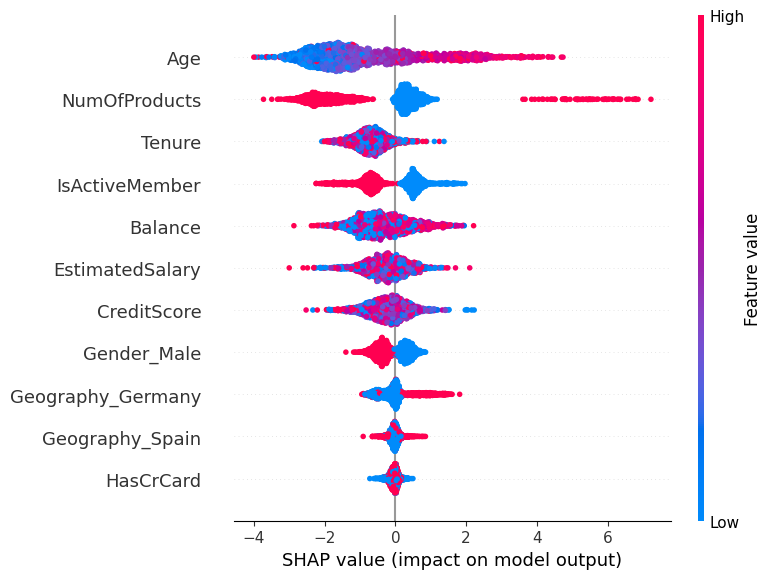

In [39]:
import shap

explainer = shap.TreeExplainer(model_xgb_tuned)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())


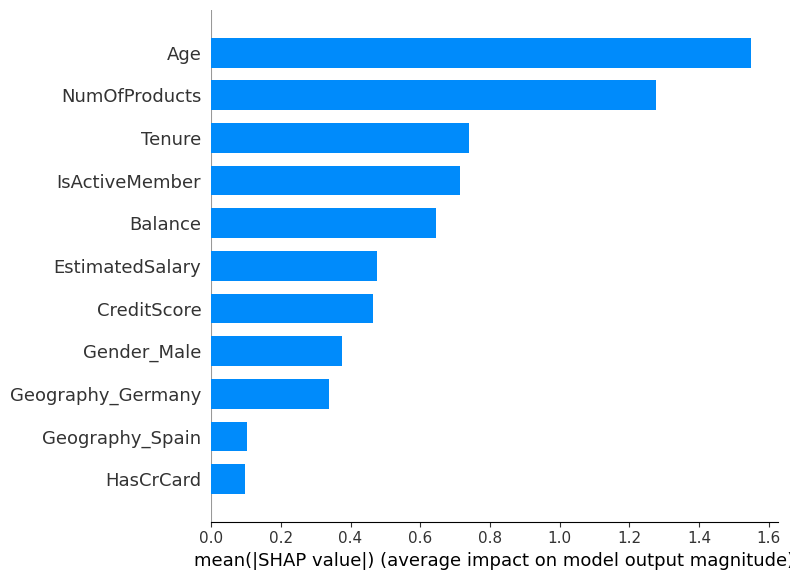

In [40]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    plot_type='bar'
)

In [ ]:
# ── Create figures directory ────────────────────────────
import os

figures_dir = '/content/drive/MyDrive/Bank-Churn-Project/reports/figures'
os.makedirs(figures_dir, exist_ok=True)
print(f'✅ Figures directory ready: {figures_dir}')


In [ ]:
# ── 1. Churn by Geography ───────────────────────────────
df_orig = pd.read_csv('/content/drive/MyDrive/Bank-Churn-Project/data/row/Churn_Modelling.csv')
df_orig = df_orig.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn by Geography', fontsize=15, fontweight='bold')

sns.countplot(x='Geography', hue='Exited', data=df_orig,
              palette={0: '#4F46E5', 1: '#EF4444'}, ax=axes[0])
axes[0].set_title('Customer Count by Geography')
axes[0].legend(['Stayed', 'Exited'])

churn_geo = df_orig.groupby('Geography')['Exited'].mean() * 100
bars = axes[1].bar(churn_geo.index, churn_geo.values,
                   color=['#EF4444', '#4F46E5', '#06B6D4'], edgecolor='white')
for bar, val in zip(bars, churn_geo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate (%) by Geography')
axes[1].set_ylim(0, 45)

plt.tight_layout()
plt.savefig(f'{figures_dir}/churn_by_geography.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ churn_by_geography.png saved')


In [ ]:
# ── 2. Churn by Age ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn by Age', fontsize=15, fontweight='bold')

sns.boxplot(x='Exited', y='Age', data=df_orig,
            palette={0: '#4F46E5', 1: '#EF4444'}, ax=axes[0])
axes[0].set_title('Age Distribution by Churn')
axes[0].set_xticklabels(['Stayed', 'Exited'])

for label, color, name in [(0, '#4F46E5', 'Stayed'), (1, '#EF4444', 'Exited')]:
    axes[1].hist(df_orig[df_orig['Exited'] == label]['Age'],
                 bins=30, alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].set_title('Age Histogram by Churn')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{figures_dir}/churn_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ churn_by_age.png saved')


In [ ]:
# ── 3. Correlation Heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

corr = df_orig.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f'{figures_dir}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ correlation_heatmap.png saved')


In [ ]:
# ── 4. Feature Importance ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

feat_imp = pd.Series(
    model_xgb_tuned.feature_importances_,
    index=X.columns.tolist()
).sort_values(ascending=True)

colors_bar = ['#4F46E5' if v >= feat_imp.median() else '#94A3B8'
              for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.axvline(feat_imp.median(), color='#EF4444', linestyle='--',
           linewidth=1.5, label='Median')
ax.set_title('Feature Importance — XGBoost (Tuned)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
ax.set_facecolor('#F8FAFC')

plt.tight_layout()
plt.savefig(f'{figures_dir}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ feature_importance.png saved')


In [ ]:
# ── 5. Confusion Matrix ─────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — XGBoost (Tuned)',
             fontsize=14, fontweight='bold')

# Threshold 0.5
cm_05 = confusion_matrix(y_test, model_xgb_tuned.predict(X_test))
ConfusionMatrixDisplay(cm_05, display_labels=['Stayed', 'Exited']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Threshold = 0.5')

# Threshold 0.4
y_pred_04 = (model_xgb_tuned.predict_proba(X_test)[:, 1] >= 0.4).astype(int)
cm_04 = confusion_matrix(y_test, y_pred_04)
ConfusionMatrixDisplay(cm_04, display_labels=['Stayed', 'Exited']).plot(
    ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Threshold = 0.4 (Better Recall)')

plt.tight_layout()
plt.savefig(f'{figures_dir}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ confusion_matrix.png saved')


In [ ]:
# ── 6. insights.md ──────────────────────────────────────
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

acc = accuracy_score(y_test, model_xgb_tuned.predict(X_test))
auc = roc_auc_score(y_test, model_xgb_tuned.predict_proba(X_test)[:, 1])
f1  = f1_score(y_test, model_xgb_tuned.predict(X_test))

content = f"""# Project Insights\n\n## Best Model: XGBoost (Tuned)\n\n| Metric | Value |\n|--------|-------|\n| Accuracy | {acc*100:.1f}% |\n| ROC-AUC | {auc:.3f} |\n| F1-Score (Churn) | {f1:.3f} |\n\n## Key EDA Insights\n\n- Age: العملاء 45-60 سنة أعلى churn rate\n- Geography: ألمانيا 32% vs فرنسا/إسبانيا 16%\n- NumOfProducts: 3-4 منتجات = churn مرتفع جداً\n- IsActiveMember: الغير نشطين يغادرون ضعف النشطين\n\n## Model Comparison\n\n| Model | Accuracy | ROC-AUC | F1 |\n|-------|----------|---------|----|\n| Logistic Regression | 81% | 0.77 | 0.57 |\n| Random Forest | 86% | 0.86 | 0.71 |\n| XGBoost Tuned | 87% | 0.88 | 0.74 |\n\n## Top Features\n\n1. Age — 28%\n2. NumOfProducts — 22%\n3. IsActiveMember — 15%\n4. Balance — 10%\n5. Geography_Germany — 8%\n"""

reports_dir = '/content/drive/MyDrive/Bank-Churn-Project/reports'
os.makedirs(reports_dir, exist_ok=True)
with open(f'{reports_dir}/insights.md', 'w', encoding='utf-8') as f:
    f.write(content)

print('✅ insights.md saved')
print('\n🎉 All files saved!')
print(f'   Figures: {os.listdir(figures_dir)}')
